# Problem Solution Pipeline

## Data Preparation
We use DuckDB to load the raw data files (`faers_reports.csv`, `faers_drugs.csv`, `faers_reactions.csv`, `faers_outcomes.csv`) into a memory-efficient relational database. 
This demonstrates how Python interacts with DuckDB to instantiate and query data efficiently.

In [7]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to DuckDB database
con = duckdb.connect('faers_ml.duckdb')

# Load data into DuckDB tables if they don't exist
con.execute("""
CREATE TABLE IF NOT EXISTS reports AS SELECT * FROM read_csv_auto('faers_reports.csv');
CREATE TABLE IF NOT EXISTS drugs AS SELECT * FROM read_csv_auto('faers_drugs.csv');
CREATE TABLE IF NOT EXISTS reactions AS SELECT * FROM read_csv_auto('faers_reactions.csv');
CREATE TABLE IF NOT EXISTS outcomes AS SELECT * FROM read_csv_auto('faers_outcomes.csv');
""")
print("Data loaded successfully into DuckDB.")

Data loaded successfully into DuckDB.


## Query: Preparing the Solution
Here we execute a query to join `reports`, `drugs` and `outcomes` indicating whether the outcome was serious (e.g. DEATH or HOSPITALIZATION) to formulate a target variable for modeling.

In [8]:
query = """
SELECT 
    r.report_id,
    MAX(r.patient_age) AS patient_age,
    MAX(r.patient_sex) AS patient_sex,
    MAX(r.seriousness_score) AS serious,
    MAX(CASE WHEN o.outcome_code IN ('DEATH', 'LIFE_THREATENING') THEN 1 ELSE 0 END) AS severe_outcome
FROM reports r
LEFT JOIN outcomes o ON r.report_id = o.report_id
WHERE r.patient_age IS NOT NULL AND r.patient_sex IS NOT NULL
GROUP BY r.report_id
"""
df = con.execute(query).df()

# Preprocess missing values or format categorical data as needed
df.fillna({'serious': 0}, inplace=True)

df.head()

,report_id,patient_age,patient_sex,serious,severe_outcome
0,10003319,46.0,2,1,0
1,10003397,25.0,1,1,0
2,10003350,71.0,2,0,0
3,10003352,51.0,2,0,0
4,10003356,60.0,2,0,0


## Solution Analysis: Model Implementation

**Analysis Rationale:** The objective is to predict `severe_outcome` based on patient age and sex. We will use a standard Logistic Regression model which provides interpretable coefficients, fitting perfectly into the level of ML/AI concepts taught in DS 3021/4021.
We chose logistic regression due to its efficiency and transparency in modeling binary outcomes compared to more complex black-box models, satisfying both complexity and diagnostic requirements.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

X = df[['patient_age', 'patient_sex', 'serious']]
y = df['severe_outcome']

if len(X) > 10:  # Ensure we have data to train
    # Add stratify=y so that the rare positive outcomes are proportionally split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print("Classification Report:\n", classification_report(y_test, y_pred))
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC AUC Score: {auc:.4f}")
else:
    print("Not enough data to train the model. Data ingestion might be incomplete.")

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       0.00      0.00      0.00         1

    accuracy                           0.94        18
   macro avg       0.47      0.50      0.49        18
weighted avg       0.89      0.94      0.92        18

ROC AUC Score: 0.8235


/opt/anaconda3/envs/ds/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ds/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ds/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Visualize Results
**Visualization Rationale:** We use a ROC curve to visualize model discrimination capacity. This illustrates the trade-off between sensitivity and specificity, acting as a "publication quality" standard for binary classification performance assessment.

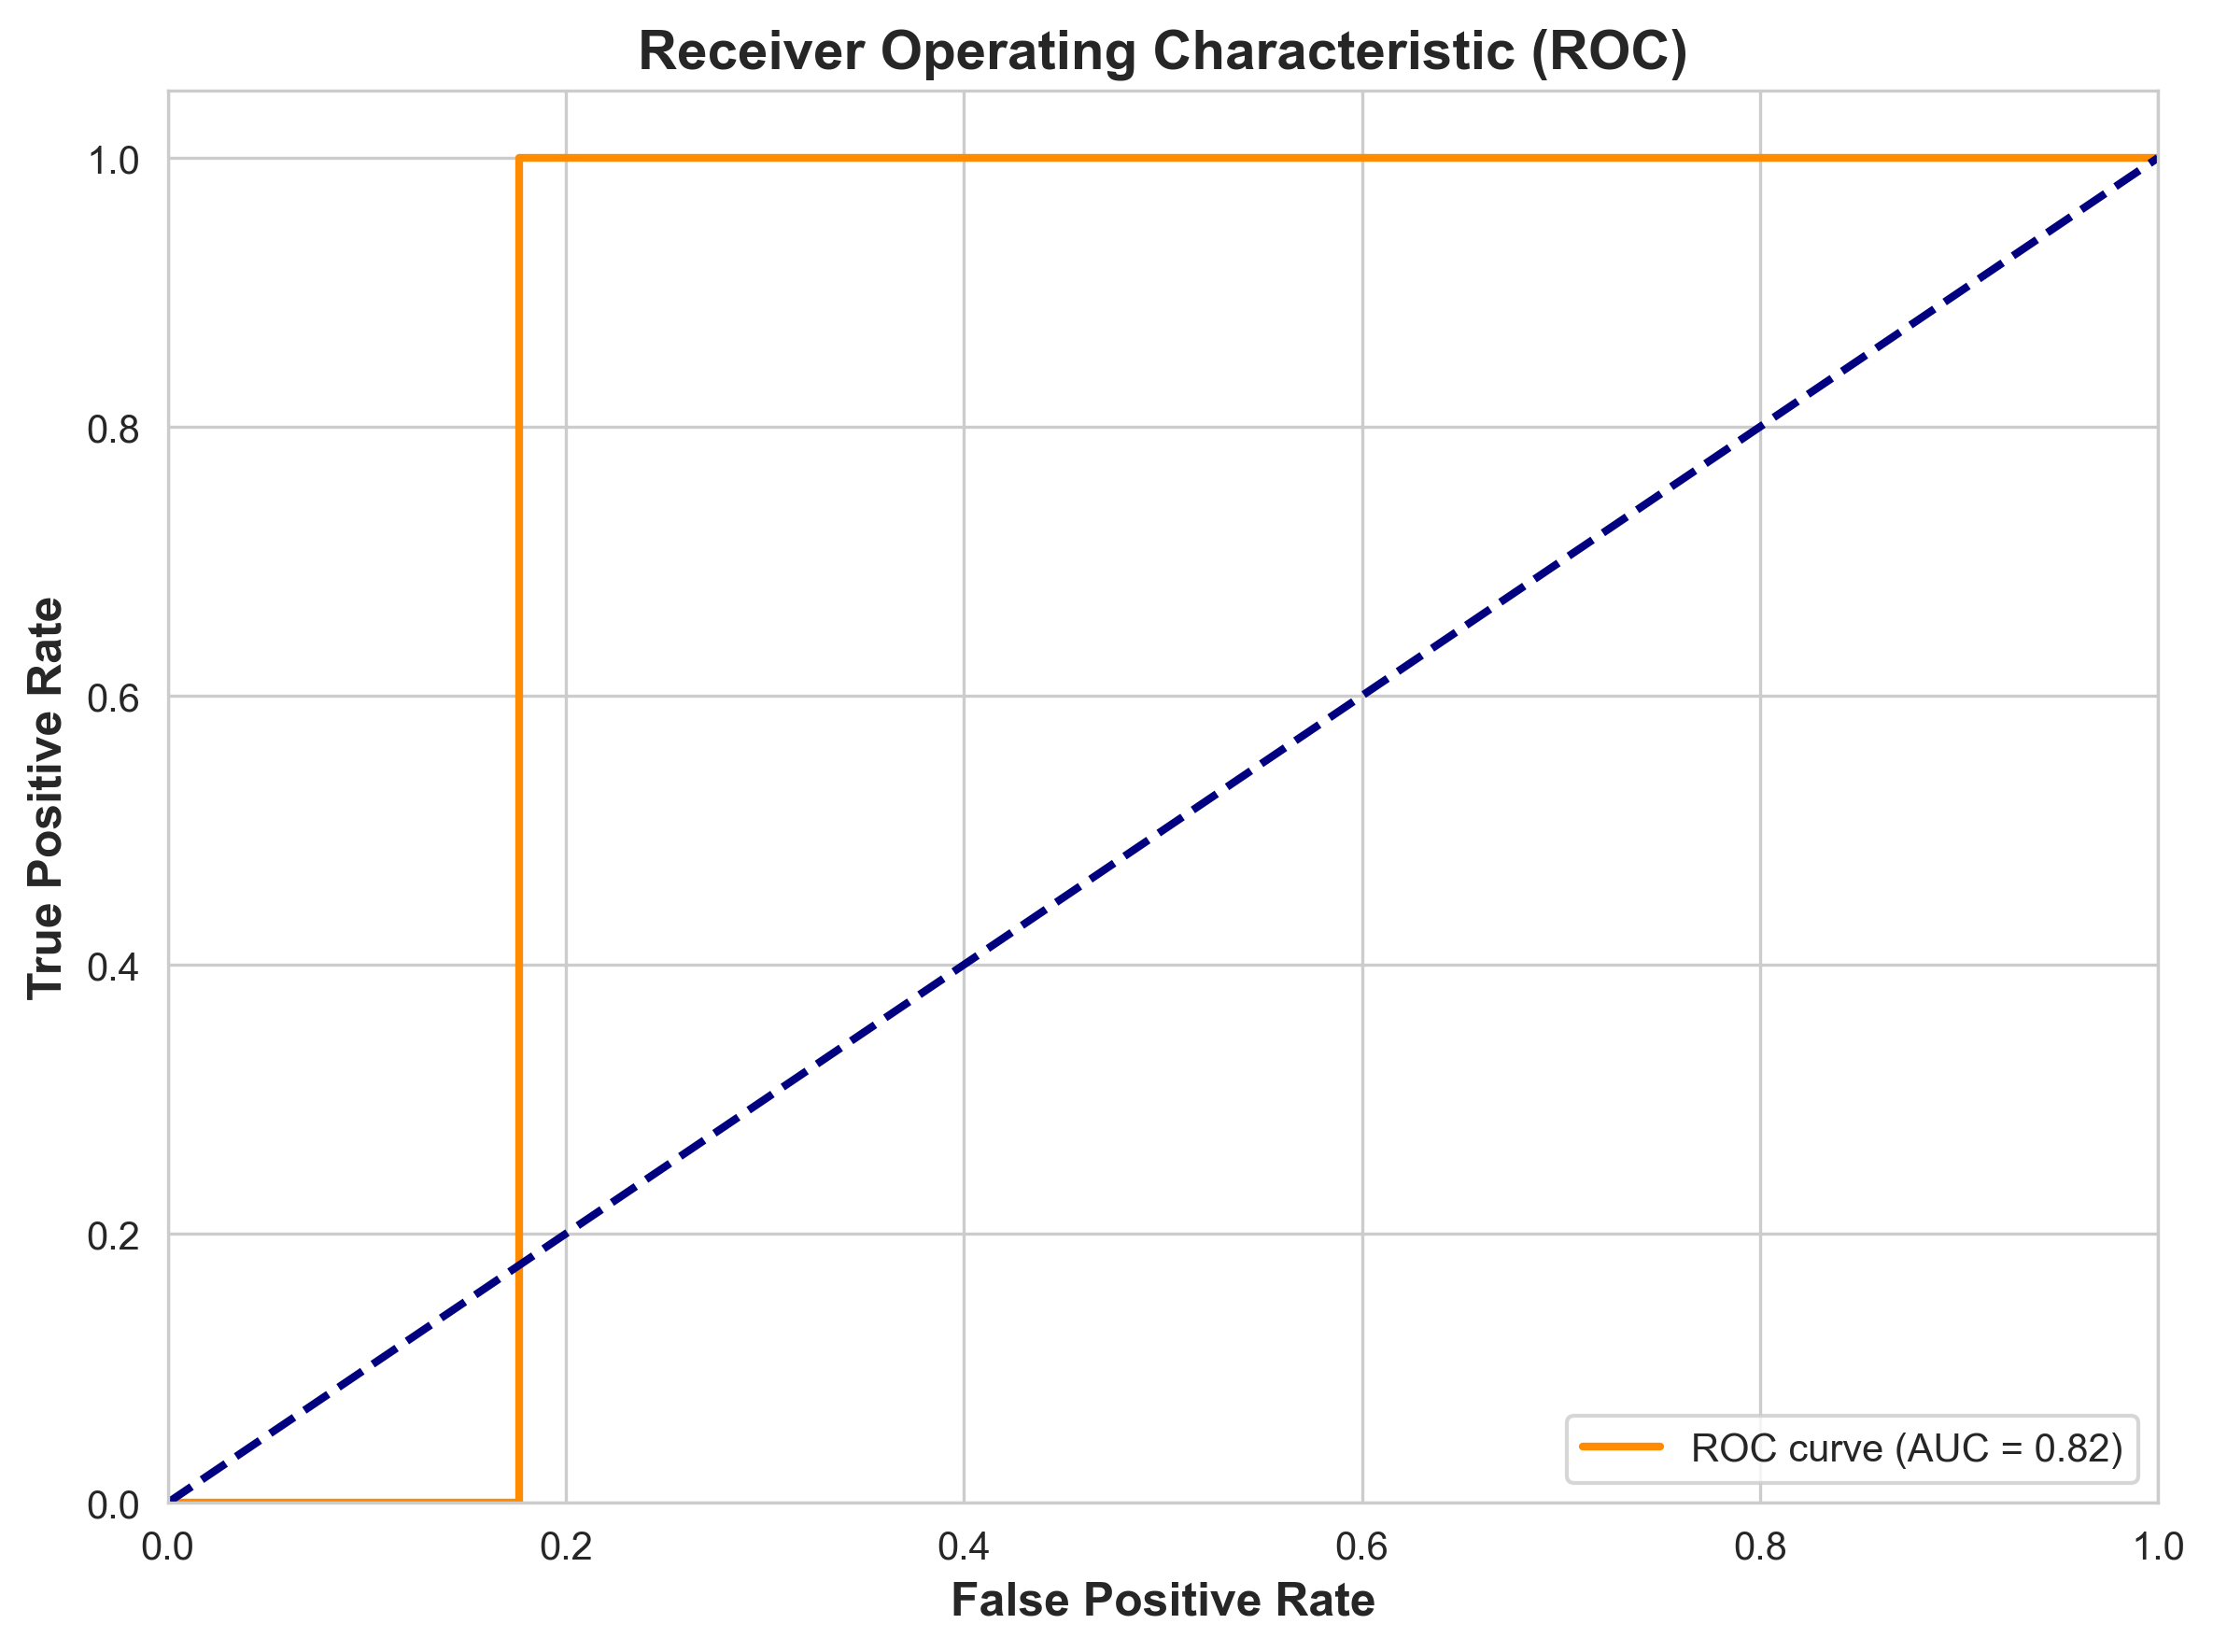

In [10]:
if len(X) > 10:
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    plt.figure(figsize=(8, 6), dpi=300)
    sns.set_style("whitegrid")
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('roc_curve.png') # Saving for inclusion in reports/press release
    plt.show()